# Визуализация метрик MPP

Графики по `metrics.csv` (loss, accuracy, learning rate). Картинки сохраняются в эту же папку.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Путь к metrics.csv (относительно этой папки или абсолютный)
METRICS_CSV = Path("../mpp_mini_output/metrics.csv")
OUT_DIR = Path(".")  # сохранять графики сюда (visualizations/)

In [2]:
df = pd.read_csv(METRICS_CSV)

train = df[df["loss"].notna()][["step", "epoch", "loss", "learning_rate"]].copy()
train = train.astype({"step": int, "loss": float})

eval_df = df[df["eval_loss"].notna()][
    ["step", "epoch", "eval_loss", "eval_accuracy_top1", "eval_accuracy_top3"]
].copy()
eval_df = eval_df.astype({
    "step": int,
    "eval_loss": float,
    "eval_accuracy_top1": float,
    "eval_accuracy_top3": float,
})

print("Train points:", len(train), "Eval points:", len(eval_df))

Train points: 418 Eval points: 418


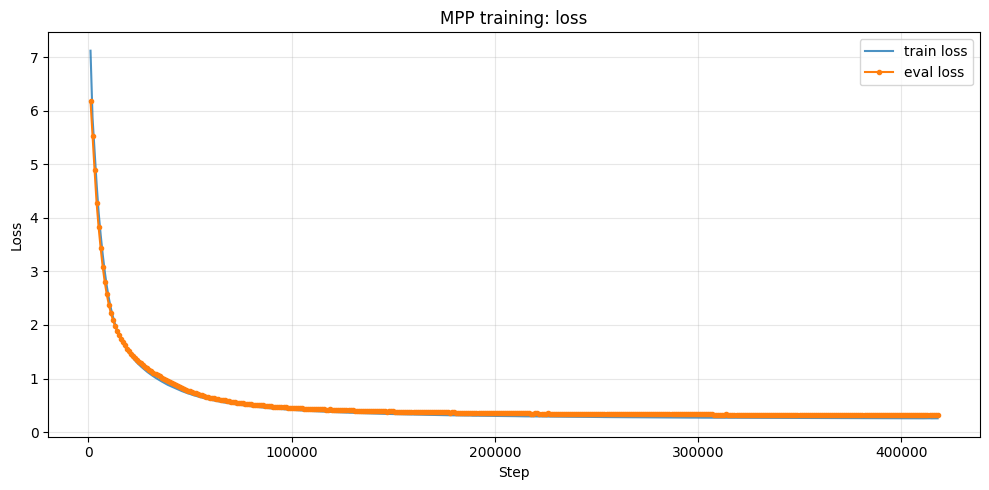

Saved: loss.png


In [3]:
fig1, ax1 = plt.subplots(figsize=(10, 5))
if not train.empty:
    ax1.plot(train["step"], train["loss"], label="train loss", color="C0", alpha=0.8)
if not eval_df.empty:
    ax1.plot(eval_df["step"], eval_df["eval_loss"], label="eval loss", color="C1", marker="o", markersize=3)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("MPP training: loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
fig1.savefig(OUT_DIR / "loss.png", dpi=150)
plt.show()
print("Saved:", OUT_DIR / "loss.png")

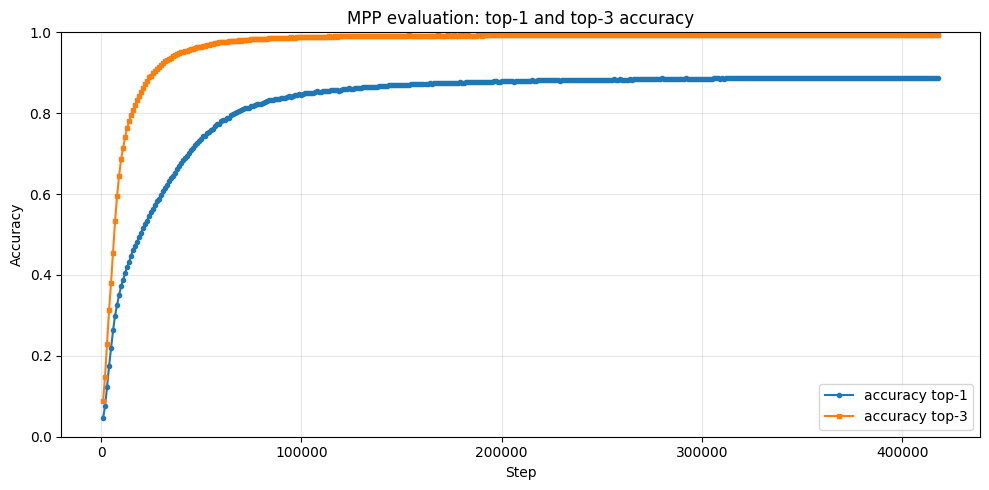

Saved: accuracy.png


In [4]:
if not eval_df.empty:
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(eval_df["step"], eval_df["eval_accuracy_top1"], label="accuracy top-1", color="C0", marker="o", markersize=3)
    ax2.plot(eval_df["step"], eval_df["eval_accuracy_top3"], label="accuracy top-3", color="C1", marker="s", markersize=3)
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("MPP evaluation: top-1 and top-3 accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    fig2.tight_layout()
    fig2.savefig(OUT_DIR / "accuracy.png", dpi=150)
    plt.show()
    print("Saved:", OUT_DIR / "accuracy.png")

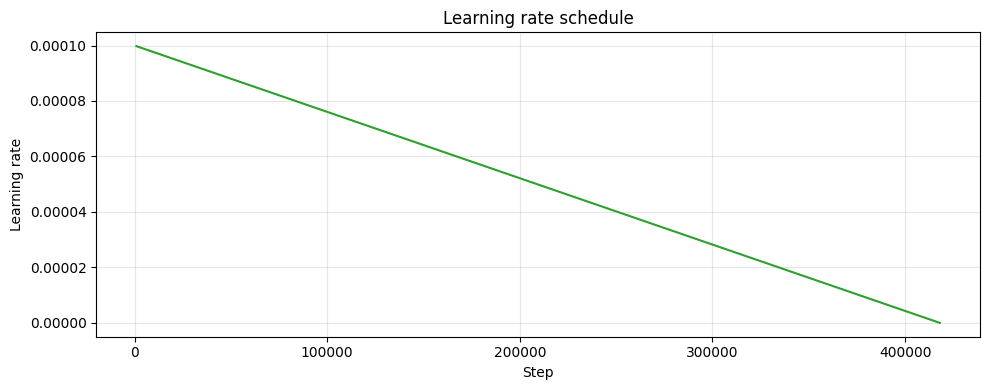

Saved: learning_rate.png


In [5]:
if not train.empty and train["learning_rate"].notna().any():
    fig3, ax3 = plt.subplots(figsize=(10, 4))
    ax3.plot(train["step"], train["learning_rate"], color="C2")
    ax3.set_xlabel("Step")
    ax3.set_ylabel("Learning rate")
    ax3.set_title("Learning rate schedule")
    ax3.grid(True, alpha=0.3)
    fig3.tight_layout()
    fig3.savefig(OUT_DIR / "learning_rate.png", dpi=150)
    plt.show()
    print("Saved:", OUT_DIR / "learning_rate.png")